# Step 2 - Feature Engineering and Daily Aggregation

**STW7085CEM Advanced Machine Learning - Task 1**  
**Title:** Bayesian Forecasting of Low-Visibility Events at Tribhuvan International Airport (VNKT, Kathmandu)  
**Student Name/ID:** Tek Raj Bhatt (250069) 

## Purpose

Transform the 165,040-row hourly cleaned table from Step 1 into the ~1,500-row **daily** modelling table that the Gaussian Process and Random Forest will be fitted on.

## The forecasting setup

This is a strict forecast, not a nowcast. For each target date *D*:

| Quantity | Window (NPT) | Source |
|---|---|---|
| **Target** | *D* 05:45 - 09:45 | minimum visibility |
| **Features** | *D*-1 18:00 -> *D* 05:00 | prior-night observations only |

A duty meteorologist at TIA at 22:00 NPT the night before a flight would have **exactly** the features the model has. The model never sees the morning it is trying to predict.

## Engineered feature families

1. **Sunset snapshot** (~18:00 NPT *D*-1) - the starting condition
2. **Pre-dawn snapshot** (~03:00 NPT *D*) - the immediate setup
3. **Overnight evolution** - changes in T, dew-point depression, pressure from sunset to pre-dawn (radiation-cooling signature)
4. **Wind regime** - mean overnight wind speed, calm fraction
5. **Sky cover** - mean overnight sky_cover_ord, clear fraction
6. **Pre-existing fog/mist** - whether BR or FG was observed during the night (independent signal)
7. **Seasonal cyclicality** - sin/cos of day-of-year

All logic lives in `scripts/build_daily_features.py`. This notebook calls it and produces sanity-check plots.

## 1. Imports and paths

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.build_daily_features import build_daily_table, setup_logging

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

HOURLY  = PROJECT_ROOT / 'data' / 'interim'   / 'vnkt_clean.parquet'
OUT     = PROJECT_ROOT / 'data' / 'processed' / 'vnkt_modelling_table.parquet'
REPORT  = PROJECT_ROOT / 'reports' / 'step2_validation.md'
FIGDIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

print('Hourly file exists:', HOURLY.exists())


Hourly file exists: True


## 2. Run the feature-engineering pipeline

Single call. Takes ~20 seconds. Produces the daily parquet plus a Markdown report.

In [2]:
logger = setup_logging(verbose=True)
daily = build_daily_table(HOURLY, OUT, REPORT, logger=logger)

print(f'\nFinal modelling table: {daily.shape[0]:,} rows x {daily.shape[1]} columns')
print(f'Date range (NPT): {daily.date_npt.min().date()} -> {daily.date_npt.max().date()}')
daily.head()


[00:46:01] INFO    Loading cleaned hourly table: /home/saggy/Desktop/advanced-ml-assignement/data/interim/vnkt_clean.parquet
[00:46:01] INFO      loaded 165,040 hourly rows
[00:46:01] INFO    Computing target variable per date...
[00:46:01] INFO      daily class distribution (all-year, pre-season-filter):
[00:46:01] INFO        Diversions-Likely (<800m):      46
[00:46:01] INFO        Delays-Likely (800-1600m):     566
[00:46:01] INFO        Normal (>=1600m):            3,173
[00:46:01] INFO    Engineering prior-night features for each target date...
[00:46:15] INFO      built features for 3,789 dates
[00:46:15] INFO      merged target+features: 3,781 rows
[00:46:15] INFO      dropped 6 dates with <2 target-window obs
[00:46:15] INFO      dropped 32 dates with <6 prior-night obs
[00:46:15] INFO      fog-season filter (Oct-Feb): 1,561 / 3,743 dates retained
[00:46:15] INFO    Wrote modelling table: /home/saggy/Desktop/advanced-ml-assignement/data/processed/vnkt_modelling_table.parquet  


Final modelling table: 1,561 rows x 25 columns
Date range (NPT): 2016-01-02 -> 2026-02-28


,date_npt,target_min_vis_m,target_class,target_morning_obs,target_fog_observed,sunset_tempc,sunset_dewpoint_depr_c,sunset_pressure_hpa,sunset_wind_speed_ms,sunset_visibility_m,...,overnight_pressure_change_hpa,night_mean_wind_speed_ms,night_calm_fraction,night_mean_sky_cover,night_clear_fraction,night_mist_observed,night_fog_observed,night_obs_count,doy_sin,doy_cos
0,2016-01-02,804.67200,1,9,1,12.5,4.5,1025.060253,1.028888,5005.05984,...,-1.015917,0.240074,0.866667,1.0,1.0,1.0,0.0,15.0,0.034398,0.999408
1,2016-01-03,997.79328,1,7,0,13.0,6.5,1021.504543,2.314998,6501.74976,...,0.507959,1.353800,0.421053,1.0,1.0,1.0,0.0,19.0,0.051584,0.998669
2,2016-01-04,997.79328,1,6,0,12.5,5.5,1019.980668,2.314998,7998.43968,...,2.031834,1.371851,0.333333,1.0,1.0,1.0,0.0,18.0,0.068755,0.997634
3,2016-01-05,48.28032,2,9,1,13.0,5.0,1022.012502,2.572220,6002.85312,...,-1.015917,1.407952,0.421053,1.0,1.0,1.0,0.0,19.0,0.085906,0.996303
4,2016-01-06,997.79328,1,7,0,13.0,6.0,1019.472710,2.057776,7000.64640,...,1.523875,1.457591,0.277778,1.0,1.0,1.0,0.0,18.0,0.103031,0.994678


## 3. Validation report

In [3]:
from IPython.display import Markdown
Markdown(REPORT.read_text())


# Step 2 Validation Report - daily modelling table

## Pipeline counts

- Hourly rows loaded from Step 1 :   165,040
- Candidate target dates         :     3,785
- Dates after observation QC     :     3,743
- Dates after fog-season filter  :     1,561

- Date range (NPT) : 2016-01-02 -> 2026-02-28

## Final daily class distribution (Oct-Feb only)

| Class | Threshold | Count | Share |
|---|---|---:|---:|
| Diversions-Likely | vis < 800 m       | 43 | 2.75% |
| Delays-Likely     | 800 <= vis < 1600m| 389 | 24.92% |
| Normal            | vis >= 1600 m     | 1,129 | 72.33% |

## Feature missingness (% NaN in final table)

| Feature | % missing |
|---|---:|
| `overnight_pressure_change_hpa` | 3.84% |
| `sunset_pressure_hpa` | 3.01% |
| `overnight_temp_drop_c` | 1.86% |
| `overnight_dewpoint_depr_drop_c` | 1.86% |
| `sunset_tempc` | 1.15% |
| `sunset_dewpoint_depr_c` | 1.15% |
| `sunset_wind_speed_ms` | 1.09% |
| `sunset_visibility_m` | 1.09% |
| `predawn_pressure_hpa` | 0.96% |
| `predawn_tempc` | 0.83% |
| `predawn_dewpoint_depr_c` | 0.83% |
| `night_mean_wind_speed_ms` | 0.00% |
| `night_calm_fraction` | 0.00% |
| `night_mean_sky_cover` | 0.00% |
| `night_clear_fraction` | 0.00% |
| `night_mist_observed` | 0.00% |
| `night_fog_observed` | 0.00% |
| `night_obs_count` | 0.00% |
| `doy_sin` | 0.00% |
| `doy_cos` | 0.00% |

## Cross-check: target_class vs target_fog_observed

If the threshold-based class label and the independent METAR fog-code label agree, that is evidence the dataset is internally consistent.

```
target_fog_observed  FG code seen  no FG code  Total
target_class                                        
Delays                         30         359    389
Diversions                     42           1     43
Normal                          0        1129   1129
Total                          72        1489   1561
```

## Schema

Total columns: 25, total rows: 1,561

| Column | Dtype | Role |
|---|---|---|
| `date_npt` | datetime64[ns] | identifier |
| `target_min_vis_m` | float64 | target (regression) |
| `target_class` | int64 | target (classification) |
| `target_morning_obs` | int64 | QC flag |
| `target_fog_observed` | int64 | independent label |
| `sunset_tempc` | float64 | feature |
| `sunset_dewpoint_depr_c` | float64 | feature |
| `sunset_pressure_hpa` | float64 | feature |
| `sunset_wind_speed_ms` | float64 | feature |
| `sunset_visibility_m` | float64 | feature |
| `predawn_tempc` | float64 | feature |
| `predawn_dewpoint_depr_c` | float64 | feature |
| `predawn_pressure_hpa` | float64 | feature |
| `overnight_temp_drop_c` | float64 | feature |
| `overnight_dewpoint_depr_drop_c` | float64 | feature |
| `overnight_pressure_change_hpa` | float64 | feature |
| `night_mean_wind_speed_ms` | float64 | feature |
| `night_calm_fraction` | float64 | feature |
| `night_mean_sky_cover` | float64 | feature |
| `night_clear_fraction` | float64 | feature |
| `night_mist_observed` | float64 | feature |
| `night_fog_observed` | float64 | feature |
| `night_obs_count` | float64 | feature |
| `doy_sin` | float64 | feature |
| `doy_cos` | float64 | feature |

## 4. Sanity-check plots

### 4.1 Class balance per winter season

Expectation: the Diversions-Likely minority class (~3%) should appear in every winter season, not be concentrated in one bad year. If only one season has all the Diversions, time-series CV will fail.

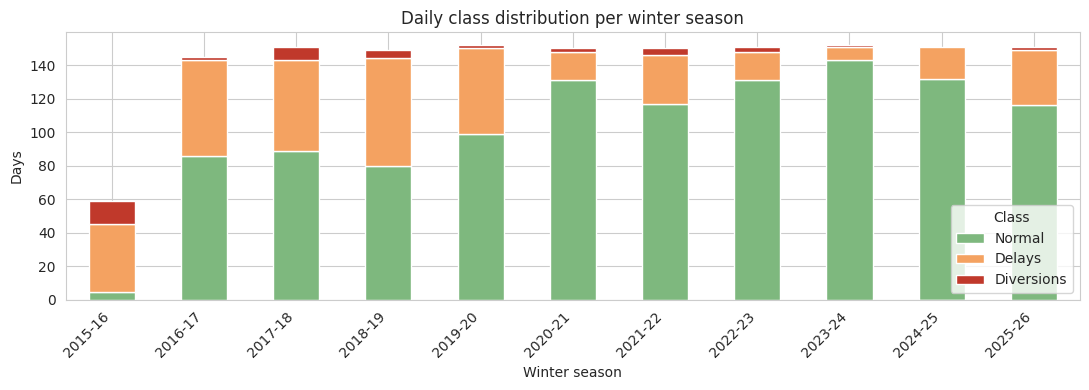


Diversion days per season:
season
2015-16    14
2016-17     2
2017-18     8
2018-19     5
2019-20     2
2020-21     2
2021-22     4
2022-23     3
2023-24     1
2024-25     0
2025-26     2
Name: Diversions, dtype: int64


In [4]:
daily['season'] = daily['date_npt'].apply(
    lambda d: f'{d.year-1}-{str(d.year)[-2:]}' if d.month <= 6 else f'{d.year}-{str(d.year+1)[-2:]}'
)
class_names = {0: 'Normal', 1: 'Delays', 2: 'Diversions'}
daily['class_name'] = daily['target_class'].map(class_names)

season_class = (
    daily.groupby(['season', 'class_name']).size()
         .unstack(fill_value=0)
         .reindex(columns=['Normal', 'Delays', 'Diversions'])
)

fig, ax = plt.subplots(figsize=(11, 4))
season_class.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#7eb87e', '#f4a261', '#c0392b'],
)
ax.set_xlabel('Winter season')
ax.set_ylabel('Days')
ax.set_title('Daily class distribution per winter season')
ax.legend(title='Class', loc='lower right')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIGDIR / 'step2_class_per_season.png', dpi=120)
plt.show()

print('\nDiversion days per season:')
print(season_class['Diversions'])


### 4.2 Feature distributions by class

Each fog-relevant feature should show a clear shift between Normal and Diversion days. If the distributions overlap completely, the feature has no predictive value and we may need to revisit the engineering.

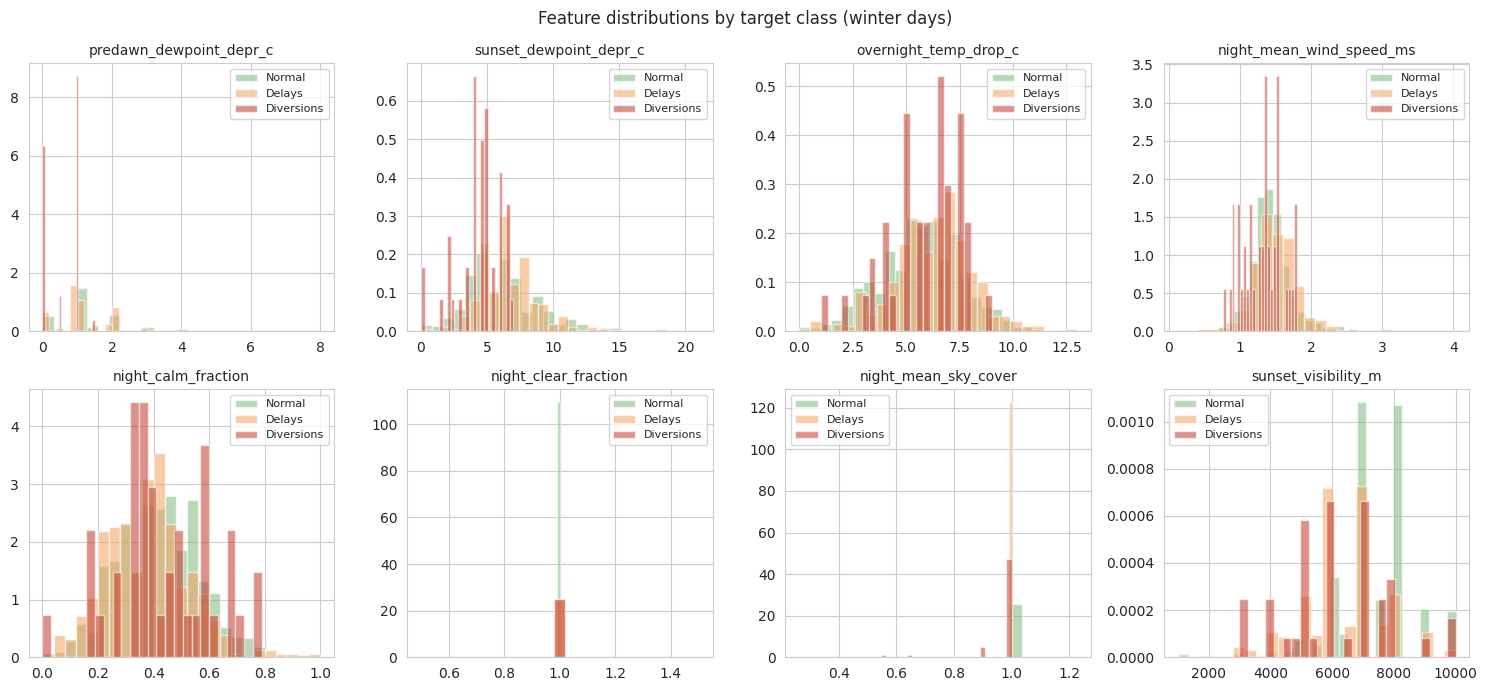

In [5]:
key_features = [
    'predawn_dewpoint_depr_c',
    'sunset_dewpoint_depr_c',
    'overnight_temp_drop_c',
    'night_mean_wind_speed_ms',
    'night_calm_fraction',
    'night_clear_fraction',
    'night_mean_sky_cover',
    'sunset_visibility_m',
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, feat in zip(axes.flatten(), key_features):
    for cls, color in zip([0, 1, 2], ['#7eb87e', '#f4a261', '#c0392b']):
        vals = daily.loc[daily['target_class'] == cls, feat].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=25, alpha=0.55, color=color,
                    label=class_names[cls], density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Feature distributions by target class (winter days)', fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR / 'step2_feature_distributions.png', dpi=120)
plt.show()


### 4.3 Independent-label cross-check

Compare `target_class` (derived from the visibility threshold rule) against `target_fog_observed` (independent METAR FG code in the morning window). If they agree on extreme days, the dataset is internally consistent.

Expectation: Normal days should have ~0% fog observations; Diversion days should have ~100%.

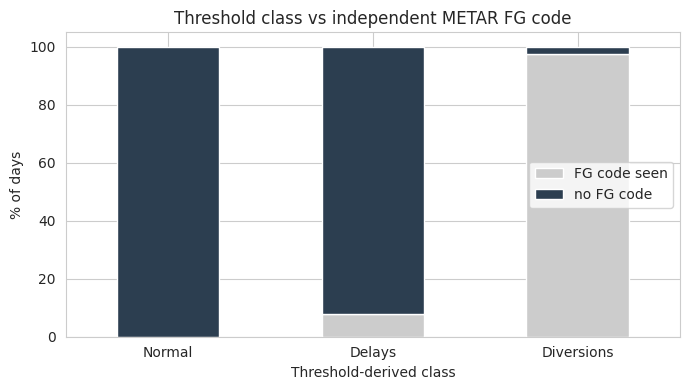

Agreement rates (% of class with FG code observed):
target_fog_observed  FG code seen  no FG code
target_class                                 
Normal                        0.0       100.0
Delays                        7.7        92.3
Diversions                   97.7         2.3


In [6]:
ct = pd.crosstab(
    daily['target_class'].map(class_names),
    daily['target_fog_observed'].map({0: 'no FG code', 1: 'FG code seen'}),
    normalize='index',
) * 100
ct = ct.reindex(['Normal', 'Delays', 'Diversions'])

fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind='bar', stacked=True, ax=ax,
        color=['#cccccc', '#2c3e50'])
ax.set_ylabel('% of days')
ax.set_xlabel('Threshold-derived class')
ax.set_title('Threshold class vs independent METAR FG code')
ax.legend(title='', loc='center right')
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(FIGDIR / 'step2_label_crosscheck.png', dpi=120)
plt.show()

print('Agreement rates (% of class with FG code observed):')
print(ct.round(1))


### 4.4 Target persistence

Yesterday's visibility is often the strongest single predictor of today's visibility. Quantify this baseline: if a Random Forest with only `sunset_visibility_m` already gets 80% R², then any GP we build must beat that bar.

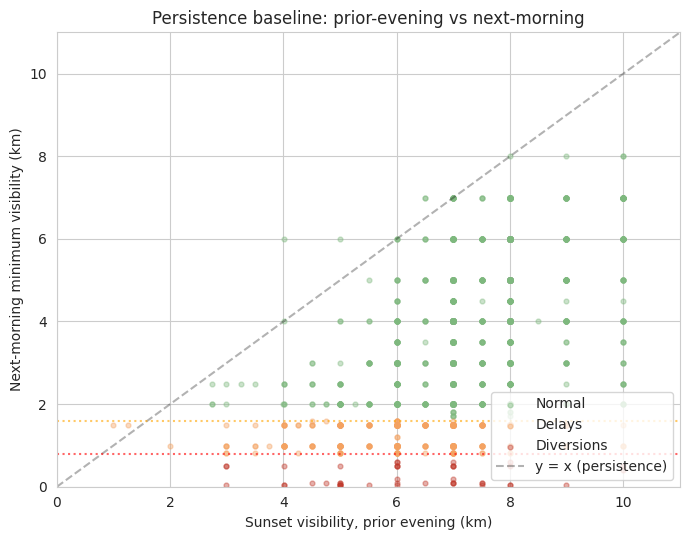

Persistence baseline (predict tomorrow = today):
  MAE: 3864 m
  R^2: -4.111


In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for cls, color, label in zip(
    [0, 1, 2],
    ['#7eb87e', '#f4a261', '#c0392b'],
    ['Normal', 'Delays', 'Diversions'],
):
    sub = daily[daily['target_class'] == cls]
    ax.scatter(
        sub['sunset_visibility_m'] / 1000,
        sub['target_min_vis_m'] / 1000,
        s=12, alpha=0.4, color=color, label=label,
    )
ax.plot([0, 11], [0, 11], 'k--', alpha=0.3, label='y = x (persistence)')
ax.axhline(1.6, ls=':', color='orange', alpha=0.6)
ax.axhline(0.8, ls=':', color='red', alpha=0.6)
ax.set_xlabel('Sunset visibility, prior evening (km)')
ax.set_ylabel('Next-morning minimum visibility (km)')
ax.set_title('Persistence baseline: prior-evening vs next-morning')
ax.legend(loc='lower right')
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
fig.tight_layout()
fig.savefig(FIGDIR / 'step2_persistence_scatter.png', dpi=120)
plt.show()

# numeric persistence baseline
from sklearn.metrics import mean_absolute_error, r2_score
mask = daily[['sunset_visibility_m', 'target_min_vis_m']].notna().all(axis=1)
y_true = daily.loc[mask, 'target_min_vis_m']
y_pred = daily.loc[mask, 'sunset_visibility_m']
print(f'Persistence baseline (predict tomorrow = today):')
print(f'  MAE: {mean_absolute_error(y_true, y_pred):.0f} m')
print(f'  R^2: {r2_score(y_true, y_pred):.3f}')


### 4.5 Final feature correlation heatmap

Same idea as the Step 1 heatmap but on the final engineered features. We want each feature to correlate with the target but not too strongly with other features (multicollinearity hurts both GP-ARD identifiability and Random Forest feature-importance interpretation).

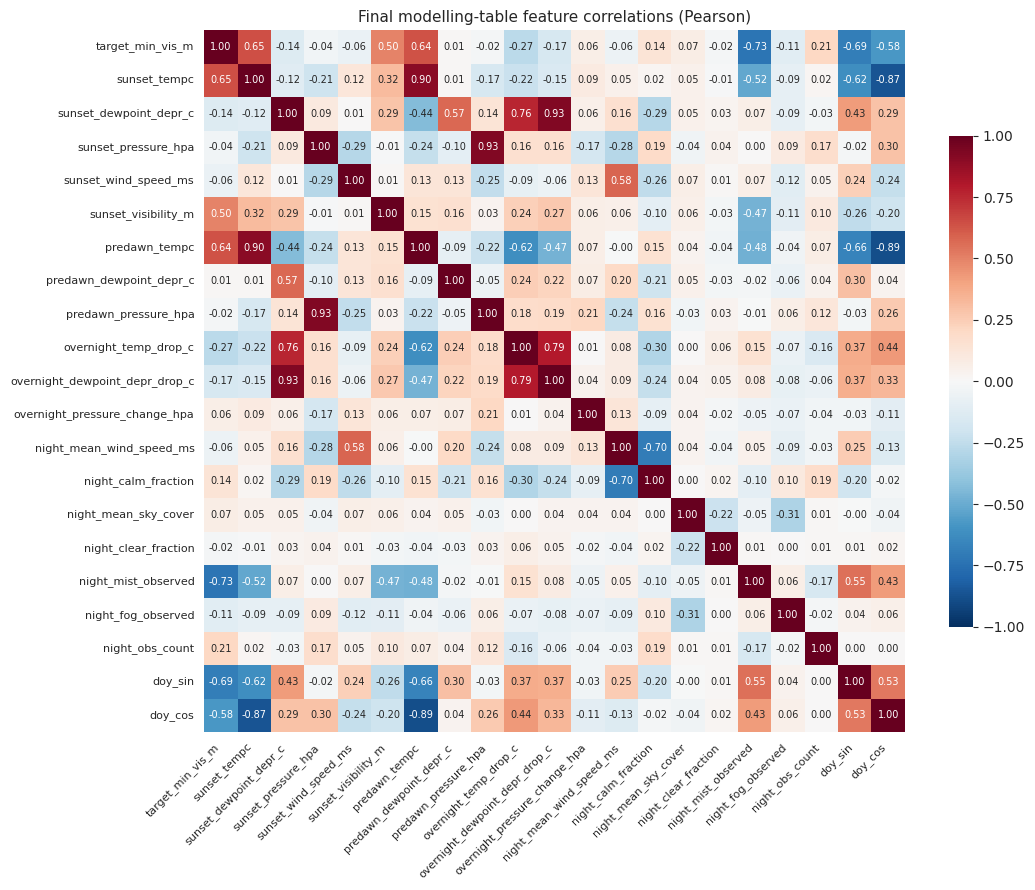

In [8]:
numeric_cols = [c for c in daily.columns
                if c not in ('date_npt','season','class_name',
                             'target_morning_obs','target_class',
                             'target_fog_observed')
                and daily[c].dtype != 'O']

corr = daily[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 7})
ax.set_title('Final modelling-table feature correlations (Pearson)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / 'step2_feature_correlations.png', dpi=120)
plt.show()


## 5. Output summary

In [9]:
outputs = {
    'Modelling parquet':          OUT,
    'Step 2 validation report':   REPORT,
    'Class per season':           FIGDIR / 'step2_class_per_season.png',
    'Feature distributions':      FIGDIR / 'step2_feature_distributions.png',
    'Label cross-check':          FIGDIR / 'step2_label_crosscheck.png',
    'Persistence scatter':        FIGDIR / 'step2_persistence_scatter.png',
    'Feature correlations':       FIGDIR / 'step2_feature_correlations.png',
}
for name, path in outputs.items():
    status = 'OK' if path.exists() else 'MISSING'
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    print(f'{status:7s}  {name:25s}  {path}  ({size_kb:,.0f} KB)')

print(f'\nFinal modelling table: {daily.shape[0]:,} rows x {daily.shape[1]} columns')


OK       Modelling parquet          /home/saggy/Desktop/advanced-ml-assignement/data/processed/vnkt_modelling_table.parquet  (61 KB)
OK       Step 2 validation report   /home/saggy/Desktop/advanced-ml-assignement/reports/step2_validation.md  (3 KB)
OK       Class per season           /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step2_class_per_season.png  (44 KB)
OK       Feature distributions      /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step2_feature_distributions.png  (121 KB)
OK       Label cross-check          /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step2_label_crosscheck.png  (29 KB)
OK       Persistence scatter        /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step2_persistence_scatter.png  (72 KB)
OK       Feature correlations       /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step2_feature_correlations.png  (340 KB)

Final modelling table: 1,561 rows x 27 columns


---

## Next step

**Step 3 - Train/Test Splits and Imputation.** With the modelling table finalised, we will:

1. Create a **forward-chaining time-series cross-validation** scheme (11 winter seasons → 6 folds, each fold trains on past seasons and tests on the next)
2. Hold out the most recent season (2025-26) as an untouched final test set
3. Impute the small residual NaN values per fold (~1-4% missingness)
4. Standardise numeric features per fold (GPs need standardised inputs)

All of this happens *per fold* to prevent leakage.